In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

file_path = "Prescribing Dataset.csv"   # change to .xlsx if needed
output_folder = "prescribing_trends_outputs"
os.makedirs(output_folder, exist_ok=True)

#  Load small sample first

In [2]:
sample = pd.read_csv(file_path, nrows=1000, low_memory=False)

print(sample.shape)
print(sample.head())
print(sample.columns.tolist())
print(sample.dtypes)

(1000, 27)
  YEAR_MONTH REGIONAL_OFFICE_NAME REGIONAL_OFFICE_CODE  \
0    2026-03             MIDLANDS                  Y60   
1    2026-03             MIDLANDS                  Y60   
2    2026-03             MIDLANDS                  Y60   
3    2026-03             MIDLANDS                  Y60   
4    2026-03             MIDLANDS                  Y60   

                                            ICB_NAME ICB_CODE  \
0  NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE ...      QWU   
1  NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE ...      QWU   
2  NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE ...      QWU   
3  NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE ...      QWU   
4  NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE ...      QWU   

                                    PCO_NAME PCO_CODE        PRACTICE_NAME  \
0  NHS COVENTRY AND WARWICKSHIRE ICB - B2M3M    B2M3M  ST WULFSTAN SURGERY   
1  NHS COVENTRY AND WARWICKSHIRE ICB - B2M3M    B2M3M  ST WULFSTAN SURGERY   
2  NHS COVENTRY

# Clean column names

In [3]:
sample.columns = sample.columns.str.strip()

# Find useful columns


In [4]:
keywords = [
    "date", "month", "year",
    "ccg", "icb", "org", "practice",
    "bnf", "drug", "chemical",
    "items", "quantity", "actual", "cost"
]

matched_cols = [
    col for col in sample.columns
    if any(k.lower() in col.lower() for k in keywords)
]

print("Matched Columns:")
print(matched_cols)

Matched Columns:
['YEAR_MONTH', 'ICB_NAME', 'ICB_CODE', 'PRACTICE_NAME', 'PRACTICE_CODE', 'BNF_CHEMICAL_SUBSTANCE_CODE', 'BNF_CHEMICAL_SUBSTANCE', 'BNF_PRESENTATION_CODE', 'BNF_PRESENTATION_NAME', 'BNF_CHAPTER_PLUS_CODE', 'QUANTITY', 'ITEMS', 'TOTAL_QUANTITY', 'ACTUAL_COST']


In [5]:
output_folder = "prescribing_eda_outputs"

os.makedirs(output_folder, exist_ok=True)

# DEFINE COLUMNS

In [6]:
date_col = "YEAR_MONTH"

icb_name_col = "ICB_NAME"

icb_code_col = "ICB_CODE"

practice_name_col = "PRACTICE_NAME"

practice_code_col = "PRACTICE_CODE"

chemical_code_col = "BNF_CHEMICAL_SUBSTANCE_CODE"

chemical_name_col = "BNF_CHEMICAL_SUBSTANCE"

presentation_code_col = "BNF_PRESENTATION_CODE"

presentation_name_col = "BNF_PRESENTATION_NAME"

bnf_col = "BNF_CHAPTER_PLUS_CODE"

quantity_col = "QUANTITY"

items_col = "ITEMS"

total_quantity_col = "TOTAL_QUANTITY"

cost_col = "ACTUAL_COST"

# BASIC DATASET INFO

In [7]:
print("Rows:", sample.shape[0])

print("Columns:", sample.shape[1])

Rows: 1000
Columns: 27


In [8]:
print(sample.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   YEAR_MONTH                   1000 non-null   object 
 1   REGIONAL_OFFICE_NAME         1000 non-null   object 
 2   REGIONAL_OFFICE_CODE         1000 non-null   object 
 3   ICB_NAME                     1000 non-null   object 
 4   ICB_CODE                     1000 non-null   object 
 5   PCO_NAME                     1000 non-null   object 
 6   PCO_CODE                     1000 non-null   object 
 7   PRACTICE_NAME                1000 non-null   object 
 8   PRACTICE_CODE                1000 non-null   object 
 9   ADDRESS_1                    1000 non-null   object 
 10  ADDRESS_2                    940 non-null    object 
 11  ADDRESS_3                    1000 non-null   object 
 12  ADDRESS_4                    810 non-null    object 
 13  POSTCODE           

In [9]:
print(sample.dtypes)

YEAR_MONTH                      object
REGIONAL_OFFICE_NAME            object
REGIONAL_OFFICE_CODE            object
ICB_NAME                        object
ICB_CODE                        object
PCO_NAME                        object
PCO_CODE                        object
PRACTICE_NAME                   object
PRACTICE_CODE                   object
ADDRESS_1                       object
ADDRESS_2                       object
ADDRESS_3                       object
ADDRESS_4                       object
POSTCODE                        object
BNF_CHEMICAL_SUBSTANCE_CODE     object
BNF_CHEMICAL_SUBSTANCE          object
BNF_PRESENTATION_CODE           object
BNF_PRESENTATION_NAME           object
BNF_CHAPTER_PLUS_CODE           object
QUANTITY                       float64
ITEMS                            int64
TOTAL_QUANTITY                 float64
ADQ_USAGE                      float64
NIC                            float64
ACTUAL_COST                    float64
UNIDENTIFIED             

In [10]:
print(sample.columns.tolist())

['YEAR_MONTH', 'REGIONAL_OFFICE_NAME', 'REGIONAL_OFFICE_CODE', 'ICB_NAME', 'ICB_CODE', 'PCO_NAME', 'PCO_CODE', 'PRACTICE_NAME', 'PRACTICE_CODE', 'ADDRESS_1', 'ADDRESS_2', 'ADDRESS_3', 'ADDRESS_4', 'POSTCODE', 'BNF_CHEMICAL_SUBSTANCE_CODE', 'BNF_CHEMICAL_SUBSTANCE', 'BNF_PRESENTATION_CODE', 'BNF_PRESENTATION_NAME', 'BNF_CHAPTER_PLUS_CODE', 'QUANTITY', 'ITEMS', 'TOTAL_QUANTITY', 'ADQ_USAGE', 'NIC', 'ACTUAL_COST', 'UNIDENTIFIED', 'SNOMED_CODE']


# MISSING VALUES

In [11]:
missing_report = pd.DataFrame({
    "Column": sample.columns,
    "Missing_Count": sample.isnull().sum(),
    "Missing_Percent": (
        sample.isnull().sum() / len(sample)
    ) * 100
})

missing_report = missing_report.sort_values(
    "Missing_Percent",
    ascending=False
)

print(missing_report)

                                                  Column  Missing_Count  \
ADDRESS_4                                      ADDRESS_4            190   
ADDRESS_2                                      ADDRESS_2             60   
REGIONAL_OFFICE_NAME                REGIONAL_OFFICE_NAME              0   
REGIONAL_OFFICE_CODE                REGIONAL_OFFICE_CODE              0   
ICB_NAME                                        ICB_NAME              0   
PCO_NAME                                        PCO_NAME              0   
ICB_CODE                                        ICB_CODE              0   
PCO_CODE                                        PCO_CODE              0   
PRACTICE_NAME                              PRACTICE_NAME              0   
PRACTICE_CODE                              PRACTICE_CODE              0   
YEAR_MONTH                                    YEAR_MONTH              0   
ADDRESS_1                                      ADDRESS_1              0   
ADDRESS_3                

#  Fill missing values in address columns

In [12]:
df_clean = sample.copy()

In [13]:
address_cols = ["ADDRESS_2", "ADDRESS_4"]

for col in address_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")



# Verify Missing Values

In [14]:

print("Missing Values After Handling:\n")

print(
    df_clean[address_cols].isnull().sum()
)

Missing Values After Handling:

ADDRESS_2    0
ADDRESS_4    0
dtype: int64


# Final Missing Report

In [15]:
final_missing = pd.DataFrame({
    "Column": df_clean.columns,
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percent": (
        df_clean.isnull().sum() / len(df_clean)
    ) * 100
})

print(
    final_missing.sort_values(
        "Missing_Percent",
        ascending=False
    )
)

                                                  Column  Missing_Count  \
YEAR_MONTH                                    YEAR_MONTH              0   
REGIONAL_OFFICE_NAME                REGIONAL_OFFICE_NAME              0   
REGIONAL_OFFICE_CODE                REGIONAL_OFFICE_CODE              0   
ICB_NAME                                        ICB_NAME              0   
ICB_CODE                                        ICB_CODE              0   
PCO_NAME                                        PCO_NAME              0   
PCO_CODE                                        PCO_CODE              0   
PRACTICE_NAME                              PRACTICE_NAME              0   
PRACTICE_CODE                              PRACTICE_CODE              0   
ADDRESS_1                                      ADDRESS_1              0   
ADDRESS_2                                      ADDRESS_2              0   
ADDRESS_3                                      ADDRESS_3              0   
ADDRESS_4                

# DUPLICATE CHECK

In [16]:
duplicate_rows = sample.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


# UNIQUE VALUES

In [17]:
unique_values = pd.DataFrame({
    "Column": sample.columns,
    "Unique_Values": sample.nunique()
})

print(unique_values)

                                                  Column  Unique_Values
YEAR_MONTH                                    YEAR_MONTH              1
REGIONAL_OFFICE_NAME                REGIONAL_OFFICE_NAME              5
REGIONAL_OFFICE_CODE                REGIONAL_OFFICE_CODE              5
ICB_NAME                                        ICB_NAME             11
ICB_CODE                                        ICB_CODE             11
PCO_NAME                                        PCO_NAME             15
PCO_CODE                                        PCO_CODE             15
PRACTICE_NAME                              PRACTICE_NAME             18
PRACTICE_CODE                              PRACTICE_CODE             18
ADDRESS_1                                      ADDRESS_1             18
ADDRESS_2                                      ADDRESS_2             17
ADDRESS_3                                      ADDRESS_3             16
ADDRESS_4                                      ADDRESS_4        

In [18]:
df_clean = df_clean.drop(
    columns=["UNIDENTIFIED"]
)

# Verify
print(df_clean.columns)

Index(['YEAR_MONTH', 'REGIONAL_OFFICE_NAME', 'REGIONAL_OFFICE_CODE',
       'ICB_NAME', 'ICB_CODE', 'PCO_NAME', 'PCO_CODE', 'PRACTICE_NAME',
       'PRACTICE_CODE', 'ADDRESS_1', 'ADDRESS_2', 'ADDRESS_3', 'ADDRESS_4',
       'POSTCODE', 'BNF_CHEMICAL_SUBSTANCE_CODE', 'BNF_CHEMICAL_SUBSTANCE',
       'BNF_PRESENTATION_CODE', 'BNF_PRESENTATION_NAME',
       'BNF_CHAPTER_PLUS_CODE', 'QUANTITY', 'ITEMS', 'TOTAL_QUANTITY',
       'ADQ_USAGE', 'NIC', 'ACTUAL_COST', 'SNOMED_CODE'],
      dtype='object')


In [19]:
sample = pd.read_csv("Prescribing Dataset.csv")

print(
    sample["YEAR_MONTH"].head()
)

0    2026-03
1    2026-03
2    2026-03
3    2026-03
4    2026-03
Name: YEAR_MONTH, dtype: object


# CONVERT NUMERIC COLUMNS

In [20]:
numeric_cols = [
    quantity_col,
    items_col,
    total_quantity_col,
    cost_col
]

for col in numeric_cols:

    sample[col] = pd.to_numeric(
        sample[col],
        errors="coerce"
    )

print(
    sample[numeric_cols].describe()
)

           QUANTITY         ITEMS  TOTAL_QUANTITY   ACTUAL_COST
count  1.836441e+07  1.836441e+07    1.836441e+07  1.836441e+07
mean   1.878048e+02  5.931881e+00    4.696752e+02  5.000053e+01
std    1.957411e+03  2.196100e+01    2.769264e+03  2.286347e+02
min    0.000000e+00  1.000000e+00    0.000000e+00  0.000000e+00
25%    1.500000e+01  1.000000e+00    3.000000e+01  3.997660e+00
50%    4.000000e+01  2.000000e+00    8.400000e+01  1.123657e+01
75%    9.000000e+01  4.000000e+00    2.240000e+02  3.466182e+01
max    6.300000e+06  4.667000e+03    6.300000e+06  6.497498e+04


# FILTER ANTIDEPRESSANTS & ANXIOLYTICS

In [21]:
print(
    sample[bnf_col].head(20)
)

print(
    sample[bnf_col].unique()[:20]
)

0     04: Central Nervous System
1     04: Central Nervous System
2     04: Central Nervous System
3     04: Central Nervous System
4     04: Central Nervous System
5     04: Central Nervous System
6     04: Central Nervous System
7     04: Central Nervous System
8     04: Central Nervous System
9     04: Central Nervous System
10    04: Central Nervous System
11    04: Central Nervous System
12    04: Central Nervous System
13    04: Central Nervous System
14    04: Central Nervous System
15    04: Central Nervous System
16    04: Central Nervous System
17    04: Central Nervous System
18    04: Central Nervous System
19    04: Central Nervous System
Name: BNF_CHAPTER_PLUS_CODE, dtype: object
['04: Central Nervous System' '21: Appliances'
 '22: Incontinence Appliances' '23: Stoma Appliances'
 '02: Cardiovascular System' '03: Respiratory System'
 '01: Gastro-Intestinal System' '20: Dressings' '06: Endocrine System'
 '05: Infections'
 '07: Obstetrics, Gynaecology and Urinary-Tract Disor

In [22]:
# Convert to string and remove spaces

sample[bnf_col] = (
    sample[bnf_col]
    .astype(str)
    .str.strip()
)

# Check unique values
print(sample[bnf_col].unique()[:20])

['04: Central Nervous System' '21: Appliances'
 '22: Incontinence Appliances' '23: Stoma Appliances'
 '02: Cardiovascular System' '03: Respiratory System'
 '01: Gastro-Intestinal System' '20: Dressings' '06: Endocrine System'
 '05: Infections'
 '07: Obstetrics, Gynaecology and Urinary-Tract Disorders'
 '08: Malignant Disease and Immunosuppression' '09: Nutrition and Blood'
 '10: Musculoskeletal and Joint Diseases' '11: Eye'
 '12: Ear, Nose and Oropharynx' '13: Skin' '15: Anaesthesia'
 '19: Other Drugs and Preparations'
 '14: Immunological Products and Vaccines']


In [30]:
# Filter antidepressants & anxiolytics

mh_sample = sample[
    sample[bnf_col].str.contains(
        "04|03",
        na=False
    )
].copy()

# Create drug category
mh_sample["Drug_Category"] = np.where(
    mh_sample[bnf_col].str.contains("04"),
    "Antidepressant",
    "Anxiolytic"
)

# Verify
print(
    mh_sample["Drug_Category"]
    .value_counts()
)

Drug_Category
Antidepressant    7761478
Anxiolytic        2443090
Name: count, dtype: int64


In [24]:
print(
    sorted(
        sample[bnf_col]
        .astype(str)
        .unique()
    )[:50]
)

['01: Gastro-Intestinal System', '02: Cardiovascular System', '03: Respiratory System', '04: Central Nervous System', '05: Infections', '06: Endocrine System', '07: Obstetrics, Gynaecology and Urinary-Tract Disorders', '08: Malignant Disease and Immunosuppression', '09: Nutrition and Blood', '10: Musculoskeletal and Joint Diseases', '11: Eye', '12: Ear, Nose and Oropharynx', '13: Skin', '14: Immunological Products and Vaccines', '15: Anaesthesia', '18: Preparations used in Diagnosis', '19: Other Drugs and Preparations', '20: Dressings', '21: Appliances', '22: Incontinence Appliances', '23: Stoma Appliances']


In [25]:
bnf_col = "BNF_PRESENTATION_CODE"

sample[bnf_col] = sample[bnf_col].astype(str).str.strip()

mh_sample = sample[
    sample[bnf_col].str.startswith(
        ("0401", "0403"),
        na=False
    )
].copy()

mh_sample["Drug_Category"] = np.where(
    mh_sample[bnf_col].str.startswith("0403"),
    "Antidepressant",
    "Anxiolytic"
)

print(mh_sample["Drug_Category"].value_counts())
print(mh_sample[[bnf_col, "BNF_PRESENTATION_NAME", "Drug_Category"]].head())

Drug_Category
Antidepressant    913404
Anxiolytic        340372
Name: count, dtype: int64
    BNF_PRESENTATION_CODE     BNF_PRESENTATION_NAME Drug_Category
301       0401010Z0AAAAAA   Zopiclone 7.5mg tablets    Anxiolytic
302       0401010Z0AAAAAA   Zopiclone 7.5mg tablets    Anxiolytic
303       0401010Z0AAAAAA   Zopiclone 7.5mg tablets    Anxiolytic
304       0401010Z0AAACAC  Zopiclone 3.75mg tablets    Anxiolytic
305       0401010Z0AAACAC  Zopiclone 3.75mg tablets    Anxiolytic


In [26]:
print(sample["BNF_PRESENTATION_CODE"].head(20))
print(sample["BNF_PRESENTATION_CODE"].unique()[:20])

0     0405010P0AAAAAA
1     0406000P0AAADAD
2     0406000P0AAAEAE
3     0406000S0AAABAB
4     0406000S0AAABAB
5     0406000S0AAACAC
6     0406000S0AAAGAG
7     0406000S0AAAGAG
8     0406000S0AAAKAK
9     0406000T0AAAGAG
10    0406000T0AAAGAG
11    0406000T0AAAGAG
12    0406000T0AAAGAG
13    0406000T0AAAGAG
14    0406000T0AAAKAK
15    0406000T0AAAKAK
16    0406000T0AAAKAK
17    0406000T0AAAKAK
18    0406000T0AAAKAK
19    0406000T0AAAKAK
Name: BNF_PRESENTATION_CODE, dtype: object
['0405010P0AAAAAA' '0406000P0AAADAD' '0406000P0AAAEAE' '0406000S0AAABAB'
 '0406000S0AAACAC' '0406000S0AAAGAG' '0406000S0AAAKAK' '0406000T0AAAGAG'
 '0406000T0AAAKAK' '0407010F0BGABAH' '0407010H0AAAAAA' '0407010H0AAACAC'
 '0407010H0AAAMAM' '21220000233' '21220000239' '21220000241' '21220000284'
 '21220000293' '21220000300' '21220000321']


In [32]:
sample[bnf_col] = sample[bnf_col].astype(str)

mh_sample = sample[
    sample[bnf_col].str.startswith(
        ("04", "03","01"),
        na=False
    )
].copy()

In [33]:
mh_sample["Drug_Category"] = np.where(
    mh_sample[bnf_col].str.startswith("0403"),
    
    "Antidepressant",
    
    "Anxiolytic"
)

print(
    mh_sample["Drug_Category"].value_counts()
)

Drug_Category
Anxiolytic        5943691
Antidepressant     913404
Name: count, dtype: int64


# CATEGORY DISTRIBUTION

In [34]:
Drug_Category = (
    mh_sample["Drug_Category"]
    .value_counts()
)

print(Drug_Category)

Drug_Category
Anxiolytic        5943691
Antidepressant     913404
Name: count, dtype: int64


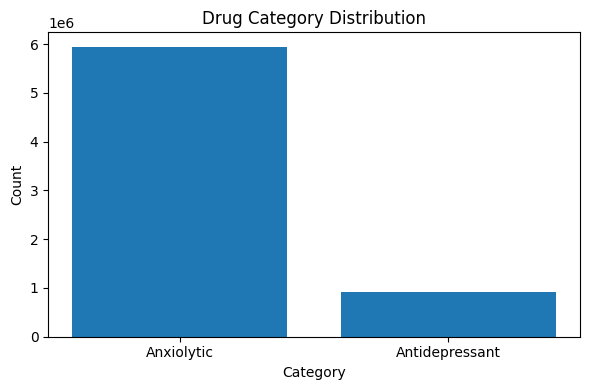

In [36]:
plt.figure(figsize=(6,4))

plt.bar(
   Drug_Category.index,
   Drug_Category.values
)

plt.title(
    "Drug Category Distribution"
)

plt.xlabel("Category")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

# TOP MEDICINES

In [37]:
top_medicines = (
    mh_sample[chemical_name_col]
    .value_counts()
    .head(20)
)

print(top_medicines)

BNF_CHEMICAL_SUBSTANCE
Co-codamol (Codeine phosphate/paracetamol)    221967
Pregabalin                                    196417
Gabapentin                                    163059
Venlafaxine                                   159518
Paracetamol                                   151361
Macrogol 3350                                 147903
Quetiapine                                    143889
Morphine sulfate                              136270
Omeprazole                                    121647
Amitriptyline hydrochloride                   114550
Lamotrigine                                   111948
Alginic acid compound preparations            111224
Tramadol hydrochloride                        110307
Methylphenidate hydrochloride                 105971
Fluoxetine hydrochloride                      103085
Lansoprazole                                  102853
Levetiracetam                                  98945
Sertraline hydrochloride                       98779
Salbutamol             

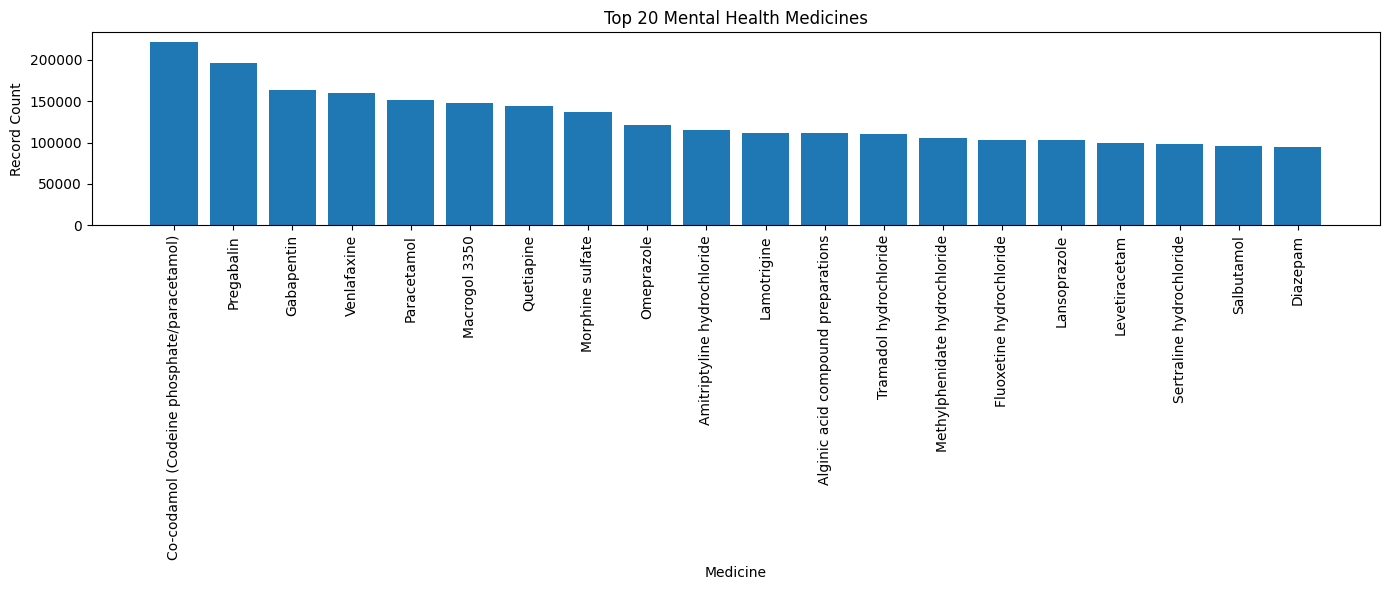

In [38]:
plt.figure(figsize=(14,6))

plt.bar(
    top_medicines.index,
    top_medicines.values
)

plt.title(
    "Top 20 Mental Health Medicines"
)

plt.xlabel("Medicine")

plt.ylabel("Record Count")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

# ICB DISTRIBUTION

In [39]:
top_icbs = (
    mh_sample[icb_name_col]
    .value_counts()
    .head(20)
)

print(top_icbs)

ICB_NAME
NHS GREATER MANCHESTER INTEGRATED CARE BOARD                                 440044
NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CARE BOARD                       411213
NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD                            394391
NHS WEST YORKSHIRE INTEGRATED CARE BOARD                                     310801
NHS NORTH WEST LONDON INTEGRATED CARE BOARD                                  244788
NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CARE BOARD                       223905
NHS NORTH EAST LONDON INTEGRATED CARE BOARD                                  218792
NHS SUSSEX INTEGRATED CARE BOARD                                             214608
NHS KENT AND MEDWAY INTEGRATED CARE BOARD                                    209883
NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD                                    198324
NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE BOARD                         195127
NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD              

C:\Users\rajmu\AppData\Local\Temp\ipykernel_23872\1341711496.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


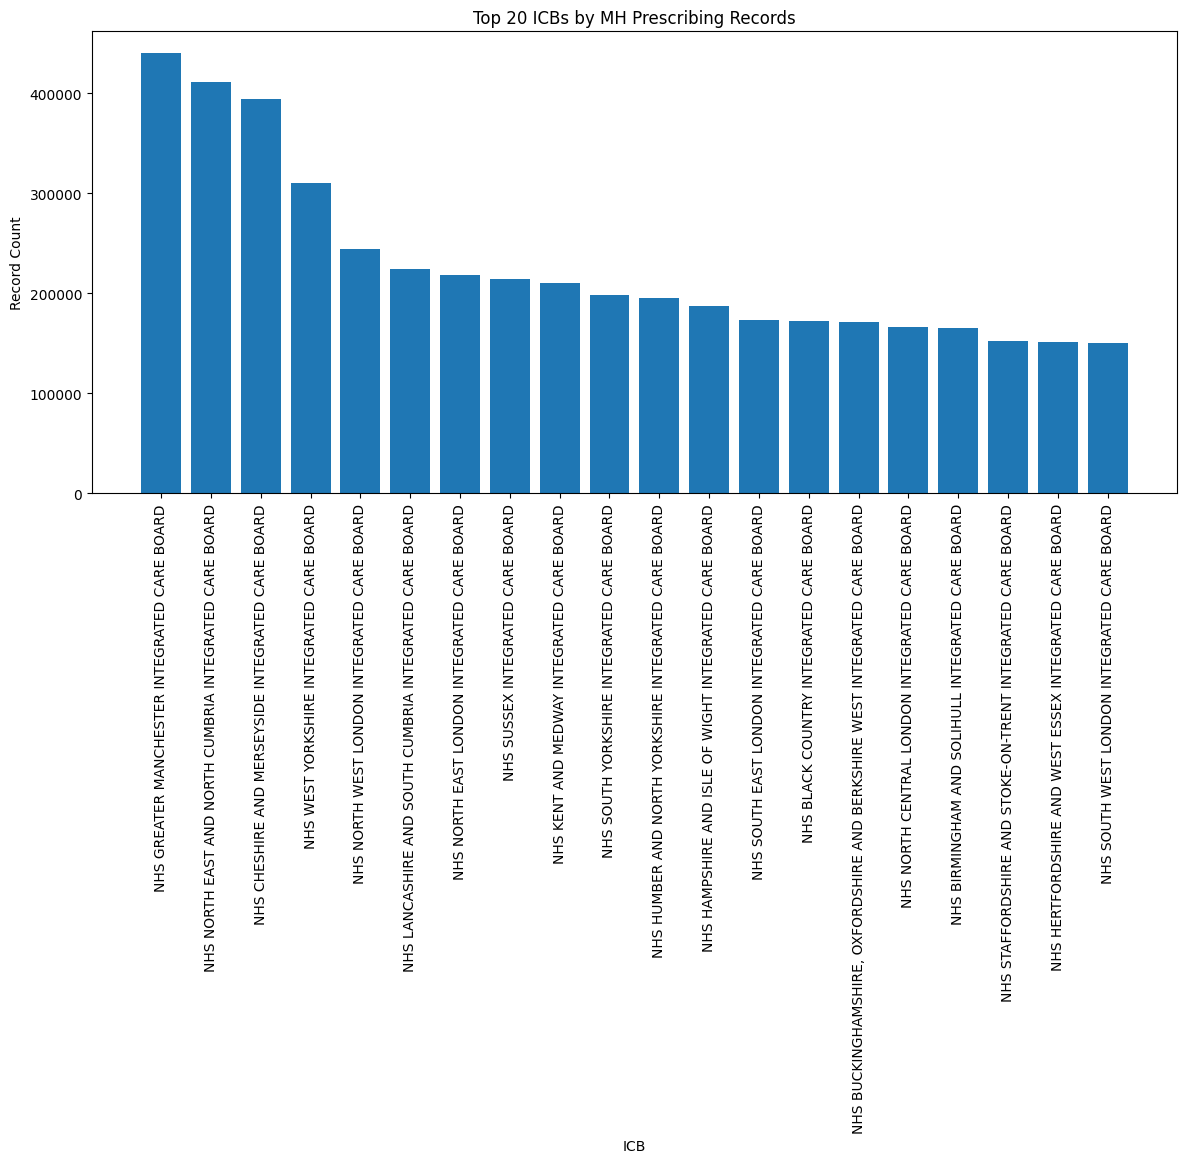

In [40]:
plt.figure(figsize=(14,6))

plt.bar(
    top_icbs.index,
    top_icbs.values
)

plt.title(
    "Top 20 ICBs by MH Prescribing Records"
)

plt.xlabel("ICB")

plt.ylabel("Record Count")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

# COST DISTRIBUTION

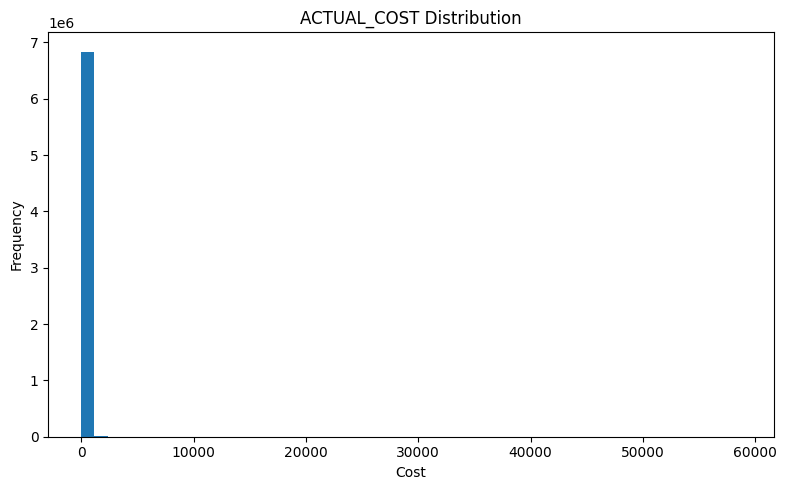

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    mh_sample[cost_col].dropna(),
    bins=50
)

plt.title(
    "ACTUAL_COST Distribution"
)

plt.xlabel("Cost")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

# ITEMS DISTRIBUTION

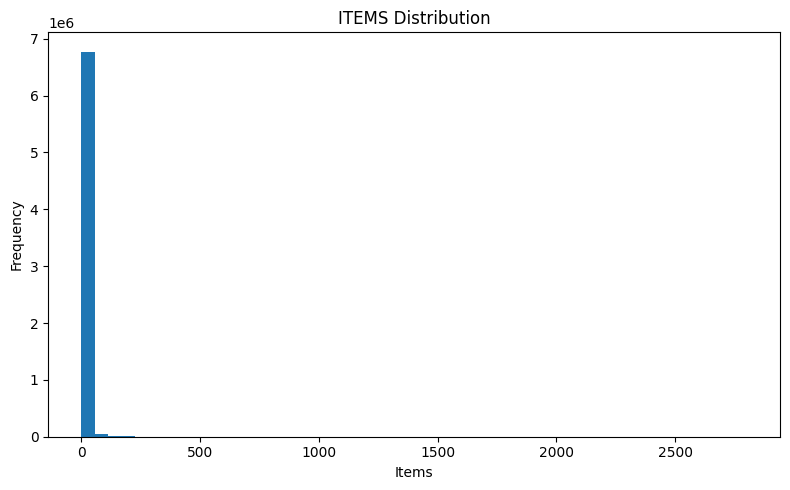

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    mh_sample[items_col].dropna(),
    bins=50
)

plt.title(
    "ITEMS Distribution"
)

plt.xlabel("Items")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

# BOXPLOTS

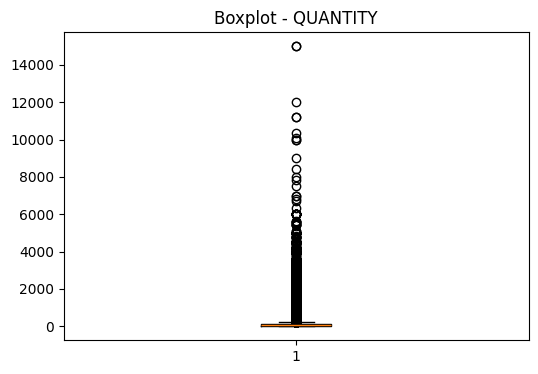

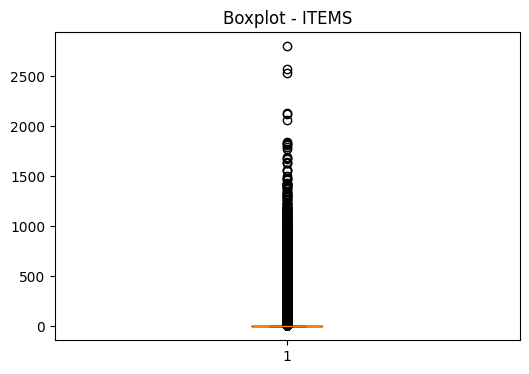

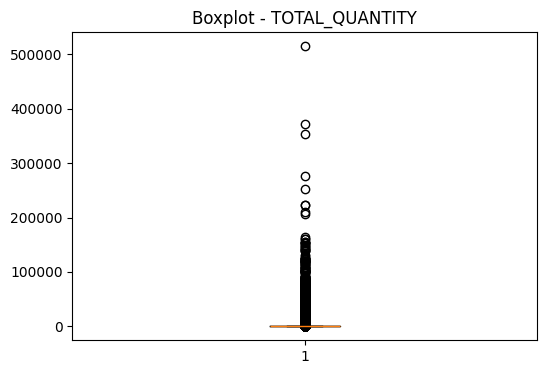

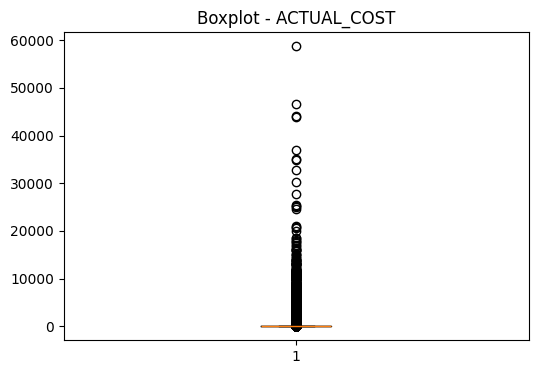

In [43]:
for col in numeric_cols:

    data = mh_sample[col].dropna()

    if len(data) > 0:

        plt.figure(figsize=(6,4))

        plt.boxplot(data)

        plt.title(f"Boxplot - {col}")

        plt.show()

# MONTHLY RECORDS

In [45]:
YEAR_MONTH = (
    mh_sample["YEAR_MONTH"]
    .value_counts()
    .sort_index()
)

print(YEAR_MONTH)

YEAR_MONTH
2026-03    6857095
Name: count, dtype: int64


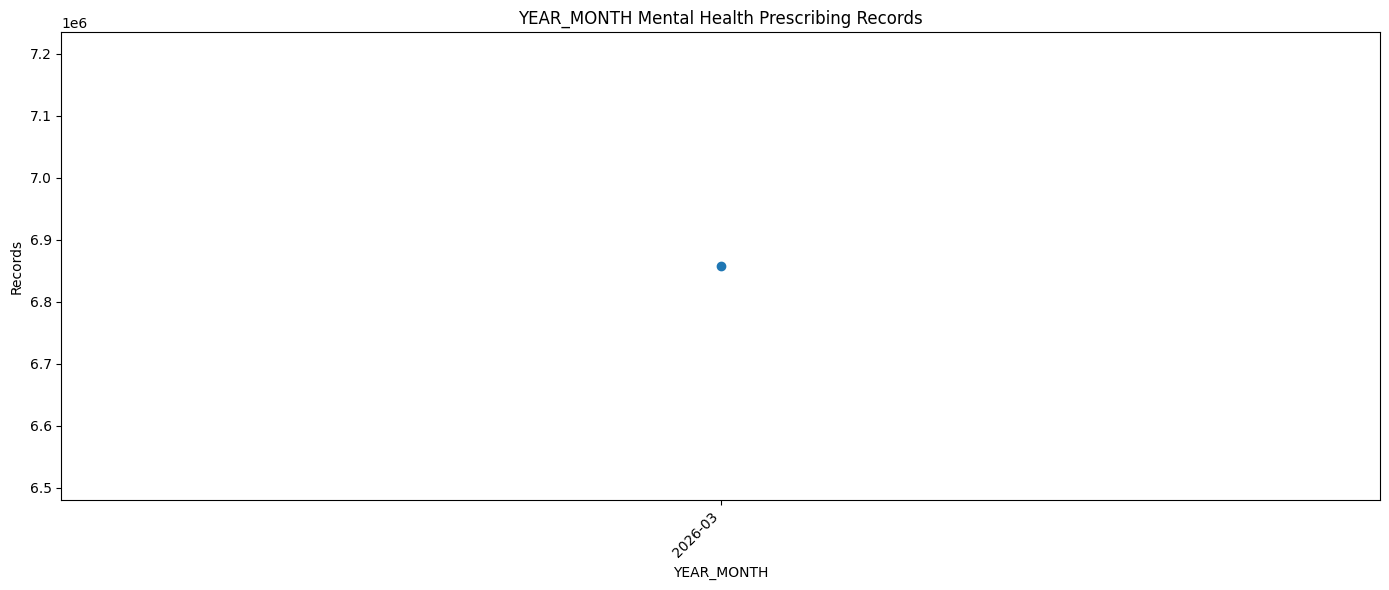

In [46]:
plt.figure(figsize=(14,6))

plt.plot(
   YEAR_MONTH.index,
    YEAR_MONTH.values,
    marker="o"
)

plt.title(
    "YEAR_MONTH Mental Health Prescribing Records"
)

plt.xlabel("YEAR_MONTH")

plt.ylabel("Records")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

# SAVE CLEAN SAMPLE

In [47]:
mh_sample.to_csv(
    f"{output_folder}/clean_mh_sample.csv",
    index=False
)

print("Clean sample saved.")

Clean sample saved.


# FINAL EDA SUMMARY

In [50]:
print("="*60)

print("EDA COMPLETED")

print("="*60)

print("Mental Health Sample Shape:")
print(mh_sample.shape)

print("\nDrug Category Distribution:")
print( Drug_Category)

print("\nTop Medicines:")
print(top_medicines.head(10))

print("\nTop ICBs:")
print(top_icbs.head(10))

print("\nTotal ITEMS:")
print(mh_sample[items_col].sum())

print("\nTotal ACTUAL COST:")
print(mh_sample[cost_col].sum())

print("="*60)

EDA COMPLETED
Mental Health Sample Shape:
(6857095, 28)

Drug Category Distribution:
Drug_Category
Anxiolytic        5943691
Antidepressant     913404
Name: count, dtype: int64

Top Medicines:
BNF_CHEMICAL_SUBSTANCE
Co-codamol (Codeine phosphate/paracetamol)    221967
Pregabalin                                    196417
Gabapentin                                    163059
Venlafaxine                                   159518
Paracetamol                                   151361
Macrogol 3350                                 147903
Quetiapine                                    143889
Morphine sulfate                              136270
Omeprazole                                    121647
Amitriptyline hydrochloride                   114550
Name: count, dtype: int64

Top ICBs:
ICB_NAME
NHS GREATER MANCHESTER INTEGRATED CARE BOARD              440044
NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CARE BOARD    411213
NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD         394391
NHS WEST YORK

# MONTHLY PRESCRIBING TREND

In [53]:
# Convert YEAR_MONTH to datetime
sample["YEAR_MONTH"] = pd.to_datetime(
    sample["YEAR_MONTH"],
    errors="coerce"
)

# Create Month column from YEAR_MONTH
sample["Month"] = sample["YEAR_MONTH"].dt.strftime("%Y-%m")

# Check
print(sample[["YEAR_MONTH", "Month"]].head())

  YEAR_MONTH    Month
0 2026-03-01  2026-03
1 2026-03-01  2026-03
2 2026-03-01  2026-03
3 2026-03-01  2026-03
4 2026-03-01  2026-03


In [54]:
bnf_col = "BNF_PRESENTATION_CODE"

sample[bnf_col] = sample[bnf_col].astype(str).str.strip()

mh_sample = sample[
    sample[bnf_col].str.startswith(("0401", "0403"), na=False)
].copy()

mh_sample["Drug_Category"] = np.where(
    mh_sample[bnf_col].str.startswith("0403"),
    "Antidepressant",
    "Anxiolytic"
)

In [55]:
monthly_trend = mh_sample.groupby(
    ["Month", "Drug_Category"],
    as_index=False
).agg(
    Total_Items=(items_col, "sum"),
    
    Total_Quantity=(total_quantity_col, "sum"),
    
    Total_Cost=(cost_col, "sum")
)

print(monthly_trend.head())

     Month   Drug_Category  Total_Items  Total_Quantity    Total_Cost
0  2026-03  Antidepressant      8194576     298495868.0  1.844705e+07
1  2026-03      Anxiolytic      1129342      35464322.0  6.970562e+06


# SAVE MONTHLY TREND CSV

In [56]:
monthly_trend.to_csv(
    f"{output_folder}/monthly_prescribing_trend.csv",
    index=False
)

print("Monthly trend CSV saved.")

Monthly trend CSV saved.


# MONTHLY ITEMS TREND CHART

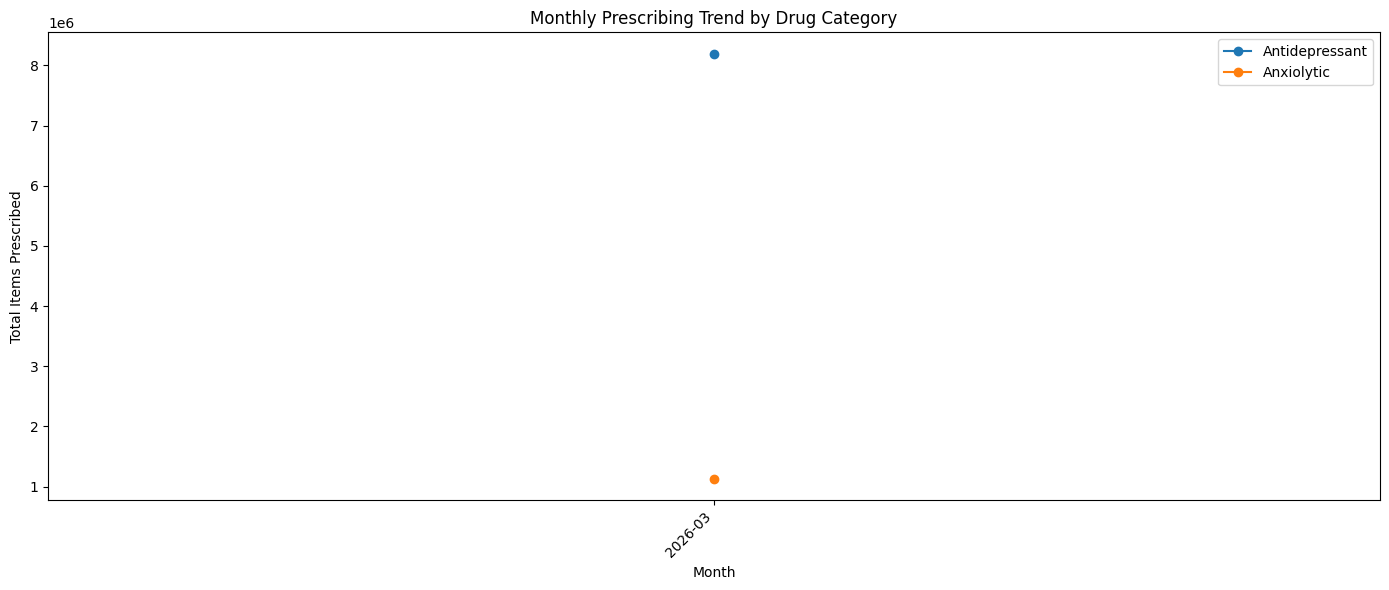

In [57]:
plt.figure(figsize=(14,6))

for category in monthly_trend["Drug_Category"].unique():

    temp = monthly_trend[
        monthly_trend["Drug_Category"] == category
    ]

    plt.plot(
        temp["Month"],
        temp["Total_Items"],
        marker="o",
        label=category
    )

plt.title(
    "Monthly Prescribing Trend by Drug Category"
)

plt.xlabel("Month")

plt.ylabel("Total Items Prescribed")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{output_folder}/monthly_items_trend.png",
    dpi=300
)

plt.show()

# MONTHLY COST TREND

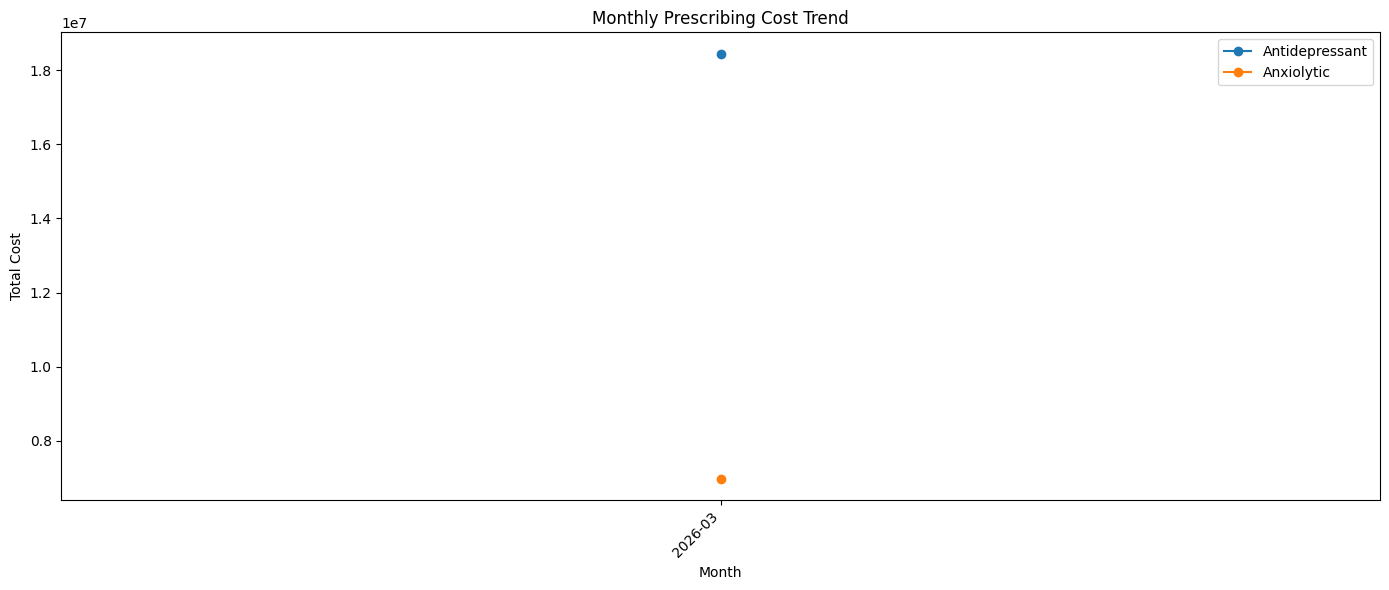

In [58]:
plt.figure(figsize=(14,6))

for category in monthly_trend["Drug_Category"].unique():

    temp = monthly_trend[
        monthly_trend["Drug_Category"] == category
    ]

    plt.plot(
        temp["Month"],
        temp["Total_Cost"],
        marker="o",
        label=category
    )

plt.title(
    "Monthly Prescribing Cost Trend"
)

plt.xlabel("Month")

plt.ylabel("Total Cost")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{output_folder}/monthly_cost_trend.png",
    dpi=300
)

plt.show()

# YEARLY TREND

In [60]:
sample["YEAR_MONTH"] = pd.to_datetime(
    sample["YEAR_MONTH"],
    errors="coerce"
)

sample["Year"] = sample["YEAR_MONTH"].dt.year
sample["Month"] = sample["YEAR_MONTH"].dt.strftime("%Y-%m")

In [64]:
bnf_col = "BNF_PRESENTATION_CODE"

sample[bnf_col] = sample[bnf_col].astype(str).str.strip()

mh_sample = sample[
    sample[bnf_col].str.startswith(("0401", "0403"), na=False)
].copy()

mh_sample["Drug_Category"] = np.where(
    mh_sample[bnf_col].str.startswith("0403"),
    "Antidepressant",
    "Anxiolytic"
)

In [65]:
yearly_trend = mh_sample.groupby(
    ["Year", "Drug_Category"],
    as_index=False
).agg(
    Total_Items=(items_col, "sum"),
    Total_Quantity=(total_quantity_col, "sum"),
    Total_Cost=(cost_col, "sum")
)

print(yearly_trend)

   Year   Drug_Category  Total_Items  Total_Quantity    Total_Cost
0  2026  Antidepressant      8194576     298495868.0  1.844705e+07
1  2026      Anxiolytic      1129342      35464322.0  6.970562e+06


In [66]:
print(mh_sample.columns)

Index(['YEAR_MONTH', 'REGIONAL_OFFICE_NAME', 'REGIONAL_OFFICE_CODE',
       'ICB_NAME', 'ICB_CODE', 'PCO_NAME', 'PCO_CODE', 'PRACTICE_NAME',
       'PRACTICE_CODE', 'ADDRESS_1', 'ADDRESS_2', 'ADDRESS_3', 'ADDRESS_4',
       'POSTCODE', 'BNF_CHEMICAL_SUBSTANCE_CODE', 'BNF_CHEMICAL_SUBSTANCE',
       'BNF_PRESENTATION_CODE', 'BNF_PRESENTATION_NAME',
       'BNF_CHAPTER_PLUS_CODE', 'QUANTITY', 'ITEMS', 'TOTAL_QUANTITY',
       'ADQ_USAGE', 'NIC', 'ACTUAL_COST', 'UNIDENTIFIED', 'SNOMED_CODE',
       'Month', 'Year', 'Drug_Category'],
      dtype='object')


# YEARLY TREND CHART

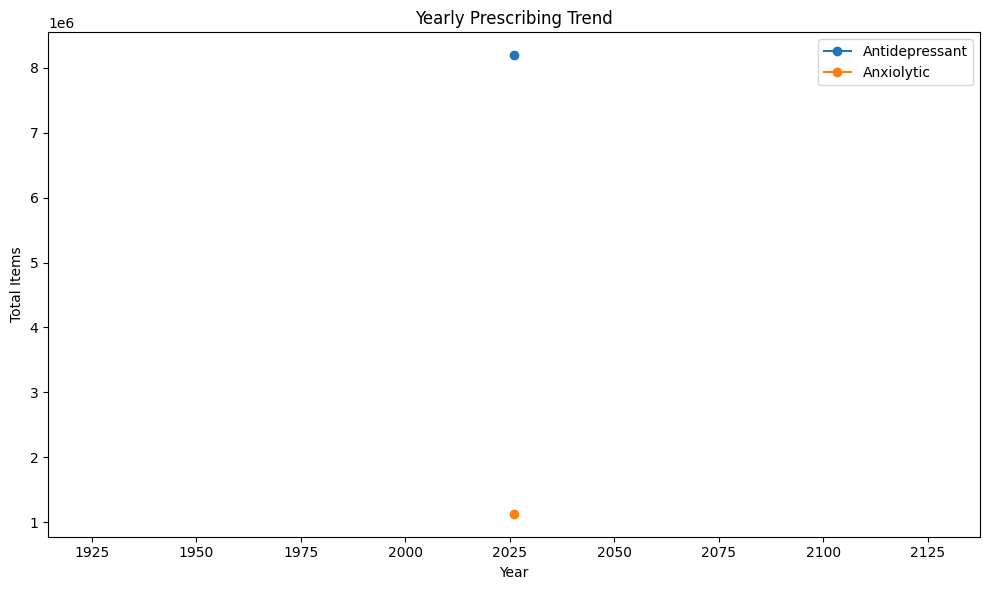

In [67]:
plt.figure(figsize=(10,6))

for category in yearly_trend["Drug_Category"].unique():

    temp = yearly_trend[
        yearly_trend["Drug_Category"] == category
    ]

    plt.plot(
        temp["Year"],
        temp["Total_Items"],
        marker="o",
        label=category
    )

plt.title(
    "Yearly Prescribing Trend"
)

plt.xlabel("Year")

plt.ylabel("Total Items")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{output_folder}/yearly_prescribing_trend.png",
    dpi=300
)

plt.show()

# ICB-LEVEL ANALYSIS

In [68]:
icb_summary = mh_sample.groupby(
    [icb_name_col, "Drug_Category"],
    as_index=False
).agg(
    Total_Items=(items_col, "sum"),
    
    Total_Quantity=(total_quantity_col, "sum"),
    
    Total_Cost=(cost_col, "sum")
)

icb_summary = icb_summary.sort_values(
    "Total_Items",
    ascending=False
)

print(icb_summary.head(20))

                                             ICB_NAME   Drug_Category  \
54  NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...  Antidepressant   
30       NHS GREATER MANCHESTER INTEGRATED CARE BOARD  Antidepressant   
14  NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD  Antidepressant   
82           NHS WEST YORKSHIRE INTEGRATED CARE BOARD  Antidepressant   
42  NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...  Antidepressant   
38  NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...  Antidepressant   
72          NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD  Antidepressant   
32  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...  Antidepressant   
40          NHS KENT AND MEDWAY INTEGRATED CARE BOARD  Antidepressant   
80                   NHS SUSSEX INTEGRATED CARE BOARD  Antidepressant   
50      NHS NORFOLK AND WAVENEY INTEGRATED CARE BOARD  Antidepressant   
56        NHS NORTH EAST LONDON INTEGRATED CARE BOARD  Antidepressant   
10  NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE.

# SAVE ICB SUMMARY

In [69]:
icb_summary.to_csv(
    f"{output_folder}/icb_prescribing_summary.csv",
    index=False
)

print("ICB summary saved.")

ICB summary saved.


# TOP ICBs FOR ANTIDEPRESSANTS

In [70]:
top_antidepressant_icb = icb_summary[
    icb_summary["Drug_Category"] == "Antidepressant"
].head(20)

print(top_antidepressant_icb)

                                             ICB_NAME   Drug_Category  \
54  NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...  Antidepressant   
30       NHS GREATER MANCHESTER INTEGRATED CARE BOARD  Antidepressant   
14  NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD  Antidepressant   
82           NHS WEST YORKSHIRE INTEGRATED CARE BOARD  Antidepressant   
42  NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...  Antidepressant   
38  NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...  Antidepressant   
72          NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD  Antidepressant   
32  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...  Antidepressant   
40          NHS KENT AND MEDWAY INTEGRATED CARE BOARD  Antidepressant   
80                   NHS SUSSEX INTEGRATED CARE BOARD  Antidepressant   
50      NHS NORFOLK AND WAVENEY INTEGRATED CARE BOARD  Antidepressant   
56        NHS NORTH EAST LONDON INTEGRATED CARE BOARD  Antidepressant   
10  NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE.

C:\Users\rajmu\AppData\Local\Temp\ipykernel_23872\4155173774.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


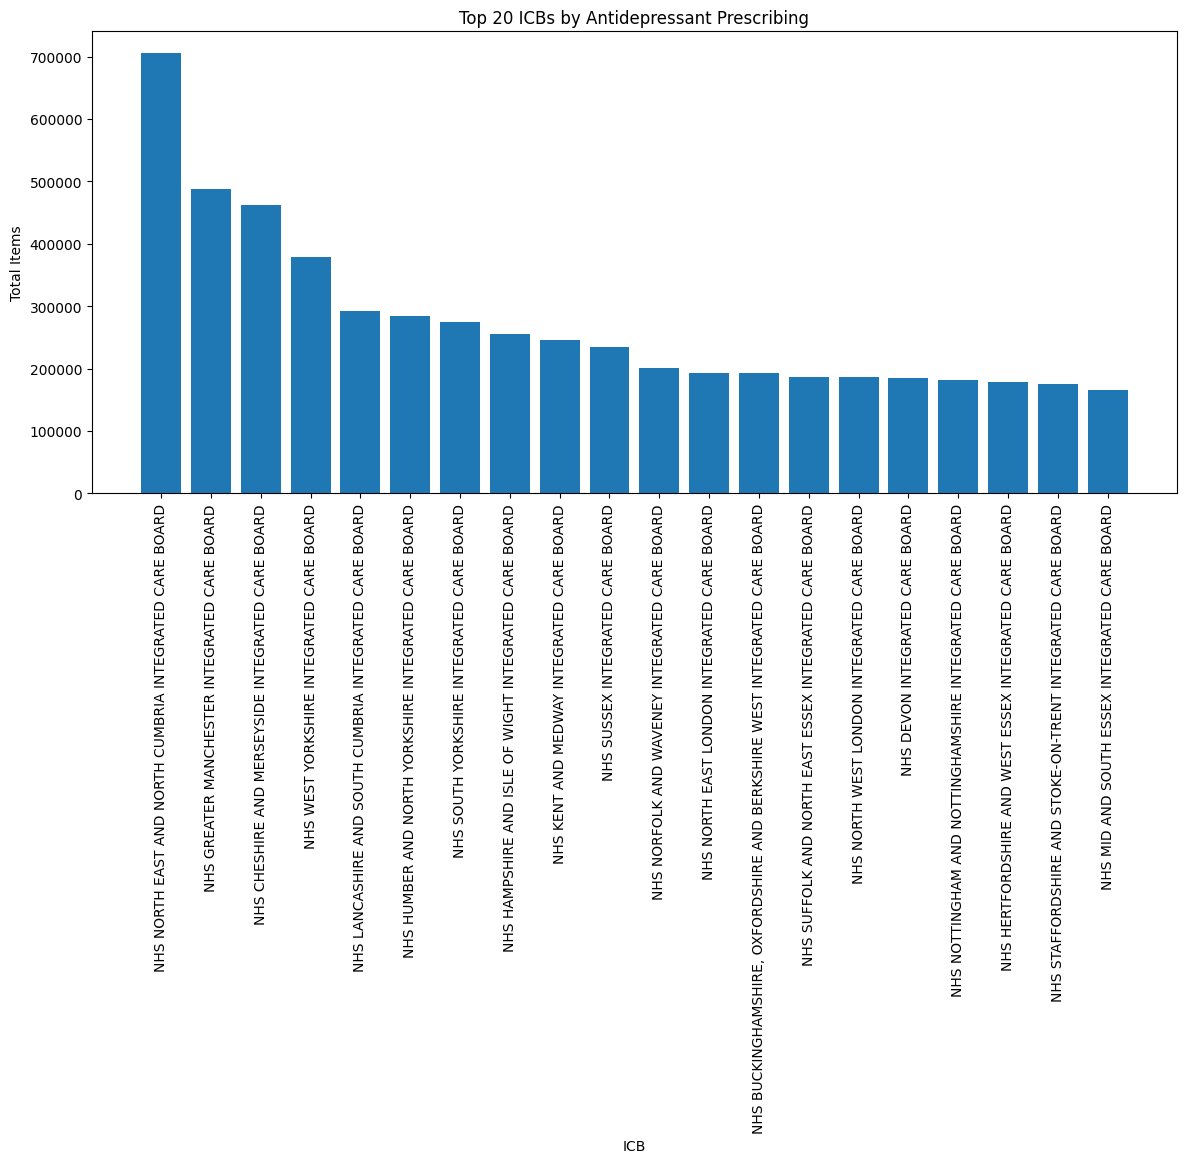

In [71]:
plt.figure(figsize=(14,6))

plt.bar(
    top_antidepressant_icb[icb_name_col],
    top_antidepressant_icb["Total_Items"]
)

plt.title(
    "Top 20 ICBs by Antidepressant Prescribing"
)

plt.xlabel("ICB")

plt.ylabel("Total Items")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.savefig(
    f"{output_folder}/top_icb_antidepressant.png",
    dpi=300
)

plt.show()

# TOP ICBs FOR ANXIOLYTICS

In [72]:
top_anxiolytic_icb = icb_summary[
    icb_summary["Drug_Category"] == "Anxiolytic"
].head(20)

print(top_anxiolytic_icb)

                                             ICB_NAME Drug_Category  \
15  NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD    Anxiolytic   
31       NHS GREATER MANCHESTER INTEGRATED CARE BOARD    Anxiolytic   
55  NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...    Anxiolytic   
81                   NHS SUSSEX INTEGRATED CARE BOARD    Anxiolytic   
83           NHS WEST YORKSHIRE INTEGRATED CARE BOARD    Anxiolytic   
33  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...    Anxiolytic   
59        NHS NORTH WEST LONDON INTEGRATED CARE BOARD    Anxiolytic   
41          NHS KENT AND MEDWAY INTEGRATED CARE BOARD    Anxiolytic   
23                    NHS DEVON INTEGRATED CARE BOARD    Anxiolytic   
53     NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD    Anxiolytic   
51      NHS NORFOLK AND WAVENEY INTEGRATED CARE BOARD    Anxiolytic   
43  NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...    Anxiolytic   
7             NHS BLACK COUNTRY INTEGRATED CARE BOARD    Anxiolytic   
73    

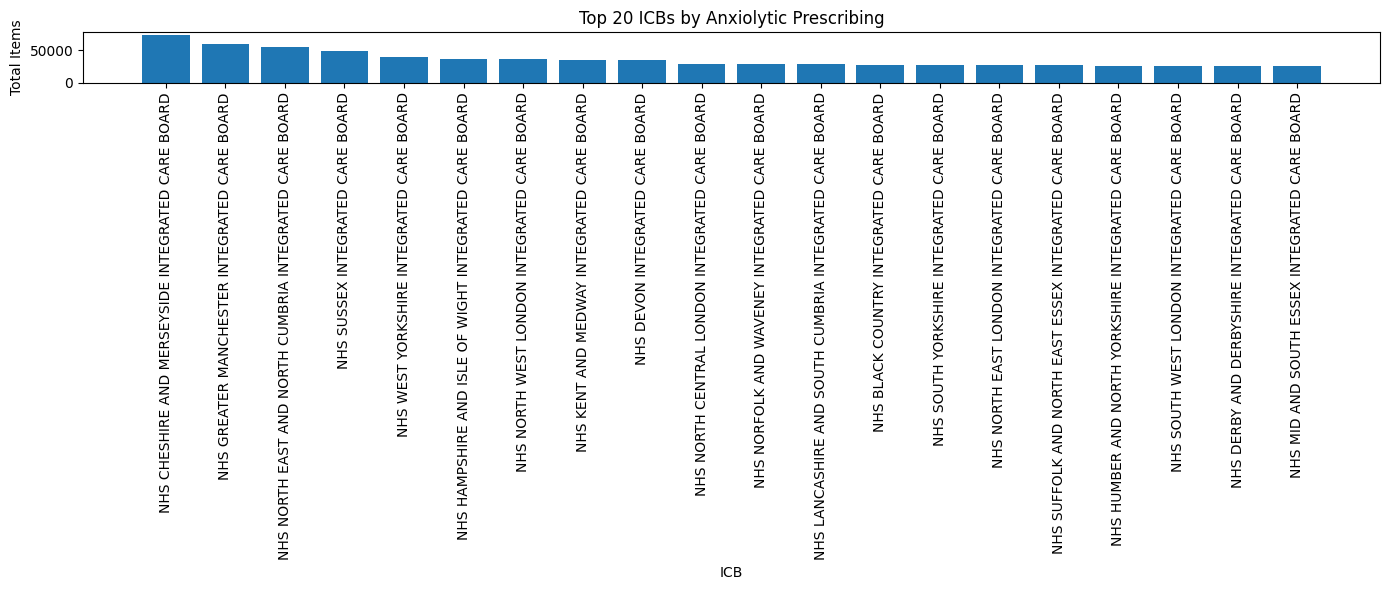

In [73]:
plt.figure(figsize=(14,6))

plt.bar(
    top_anxiolytic_icb[icb_name_col],
    top_anxiolytic_icb["Total_Items"]
)

plt.title(
    "Top 20 ICBs by Anxiolytic Prescribing"
)

plt.xlabel("ICB")

plt.ylabel("Total Items")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.savefig(
    f"{output_folder}/top_icb_anxiolytic.png",
    dpi=300
)

plt.show()

# TOP MEDICINES ANALYSIS

In [74]:
drug_summary = mh_sample.groupby(
    [chemical_name_col, "Drug_Category"],
    as_index=False
).agg(
    Total_Items=(items_col, "sum"),
    
    Total_Quantity=(total_quantity_col, "sum"),
    
    Total_Cost=(cost_col, "sum")
)

drug_summary = drug_summary.sort_values(
    "Total_Items",
    ascending=False
)

print(drug_summary.head(20))

         BNF_CHEMICAL_SUBSTANCE   Drug_Category  Total_Items  Total_Quantity  \
38     Sertraline hydrochloride  Antidepressant      2224756      73537384.0   
2   Amitriptyline hydrochloride  Antidepressant      1418271      70658240.0   
29                  Mirtazapine  Antidepressant      1188006      28913204.0   
6       Citalopram hydrobromide  Antidepressant      1072950      35334654.0   
18     Fluoxetine hydrochloride  Antidepressant       645196      29041935.0   
45                  Venlafaxine  Antidepressant       551358      19122999.0   
15     Duloxetine hydrochloride  Antidepressant       459622      15527025.0   
48                    Zopiclone      Anxiolytic       332047       5629620.0   
12                     Diazepam      Anxiolytic       305625       7977282.0   
27                    Melatonin      Anxiolytic       262547      14824543.0   
16                 Escitalopram  Antidepressant       192286       6133592.0   
42      Trazodone hydrochloride  Antidep

# SAVE DRUG SUMMARY

In [75]:
drug_summary.to_csv(
    f"{output_folder}/drug_prescribing_summary.csv",
    index=False
)

print("Drug summary saved.")

Drug summary saved.


# TOP MEDICINES CHART

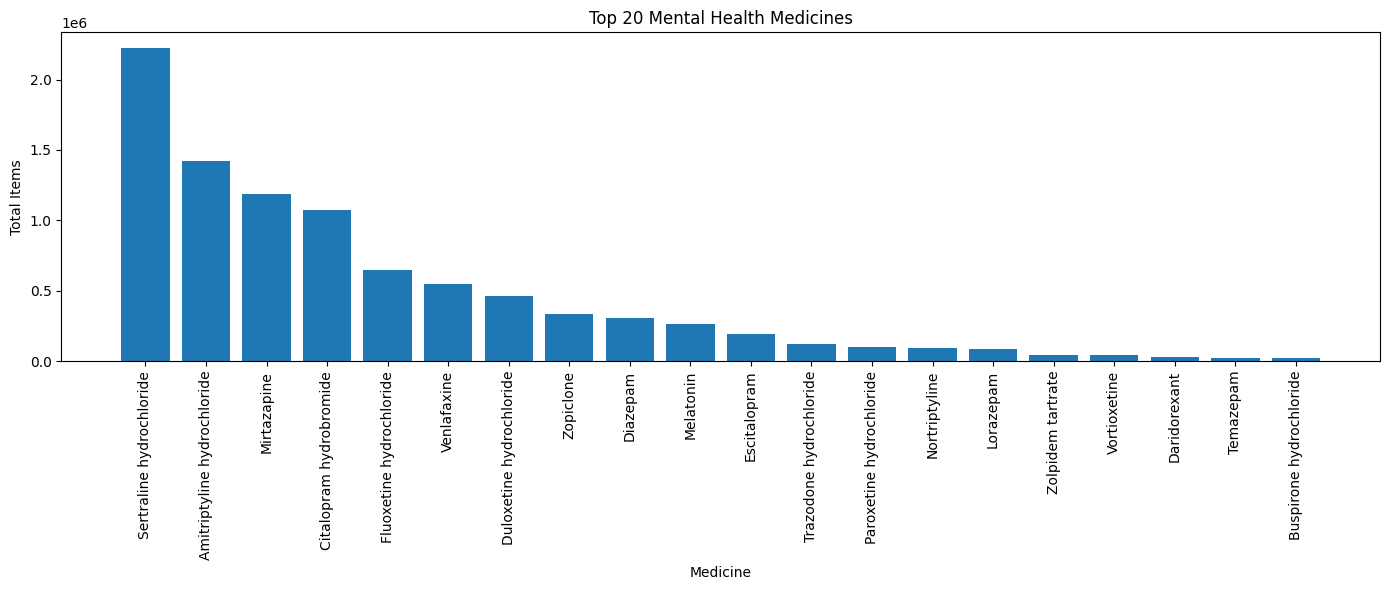

In [76]:
top_drugs = drug_summary.head(20)

plt.figure(figsize=(14,6))

plt.bar(
    top_drugs[chemical_name_col],
    top_drugs["Total_Items"]
)

plt.title(
    "Top 20 Mental Health Medicines"
)

plt.xlabel("Medicine")

plt.ylabel("Total Items")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.savefig(
    f"{output_folder}/top_20_medicines.png",
    dpi=300
)

plt.show()

# PRACTICE LEVEL ANALYSIS

In [77]:
practice_summary = mh_sample.groupby(
    [practice_name_col, "Drug_Category"],
    as_index=False
).agg(
    Total_Items=(items_col, "sum"),
    
    Total_Cost=(cost_col, "sum")
)

practice_summary = practice_summary.sort_values(
    "Total_Items",
    ascending=False
)

print(practice_summary.head(20))

                     PRACTICE_NAME   Drug_Category  Total_Items   Total_Cost
2031               CENTRAL SURGERY  Antidepressant        12986  26740.56949
13014   VALENS MEDICAL PARTNERSHIP  Antidepressant        12681  20242.92904
7542    MODALITY PARTNERSHIP (AWC)  Antidepressant        11784  28397.23888
8621                  PARK SURGERY  Antidepressant        11769  29639.82792
9512             RIVERSIDE SURGERY  Antidepressant        11680  20684.46837
9128          PRIORY MEDICAL GROUP  Antidepressant        11022  22580.25970
7297       MEDICUS HEALTH PARTNERS  Antidepressant        10282  21467.73098
12822       TRINITY MEDICAL CENTRE  Antidepressant        10151  21564.64359
12556             THE WILLOW GROUP  Antidepressant        10133  26301.71956
5433           HIGH STREET SURGERY  Antidepressant        10028  19635.67560
819              BAY MEDICAL GROUP  Antidepressant         9847  20410.09409
9002      PORTSDOWN GROUP PRACTICE  Antidepressant         9435  22984.67176

# MONTHLY ANTIDEPRESSANT VS ANXIOLYTIC COMPARISON

In [78]:
comparison_table = monthly_trend.pivot_table(
    index="Month",
    columns="Drug_Category",
    values="Total_Items"
)

print(comparison_table.head())

Drug_Category  Antidepressant  Anxiolytic
Month                                    
2026-03             8194576.0   1129342.0


# COMPARISON LINE CHART

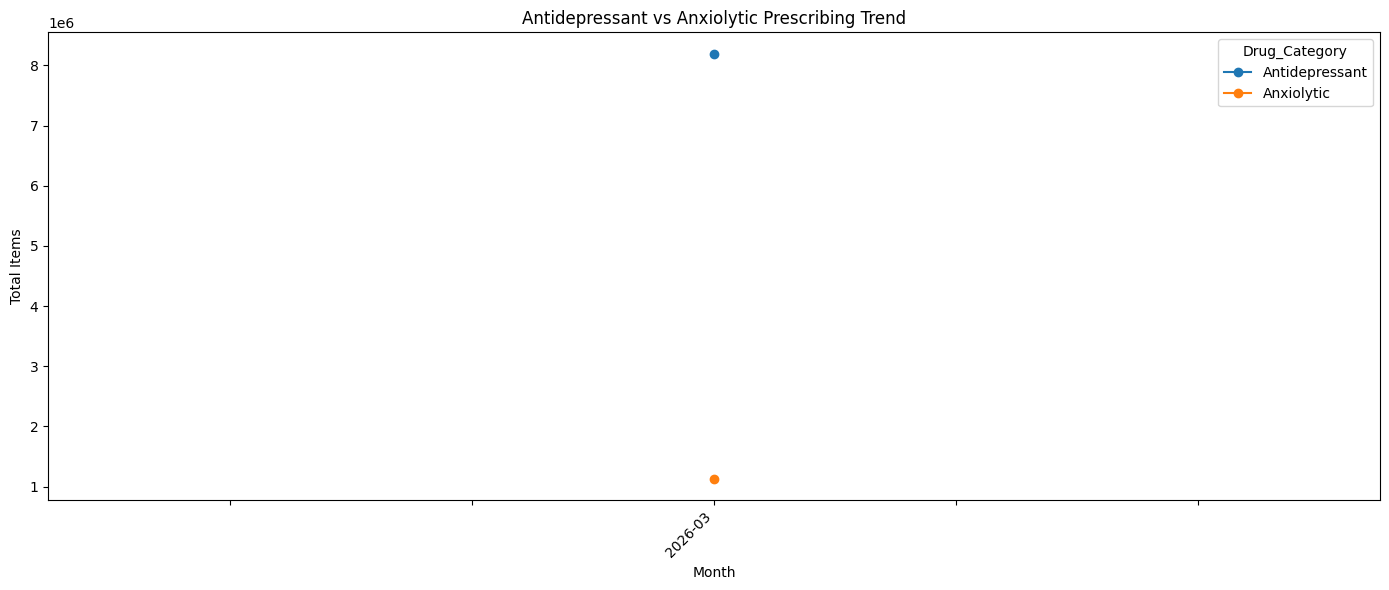

In [79]:
comparison_table.plot(
    figsize=(14,6),
    marker="o"
)

plt.title(
    "Antidepressant vs Anxiolytic Prescribing Trend"
)

plt.xlabel("Month")

plt.ylabel("Total Items")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    f"{output_folder}/comparison_trend.png",
    dpi=300
)

plt.show()

# COST HEATMAP TABLE

In [80]:
heatmap_table = mh_sample.pivot_table(
    index=icb_name_col,
    columns="Drug_Category",
    values=cost_col,
    aggfunc="sum"
)

print(heatmap_table.head())

Drug_Category                                       Antidepressant  \
ICB_NAME                                                             
NHS BATH AND NORTH EAST SOMERSET, SWINDON AND W...    276004.63210   
NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTEG...    260055.27455   
NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD     403067.52531   
NHS BLACK COUNTRY INTEGRATED CARE BOARD               386958.79099   
NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCESTE...    263335.41092   

Drug_Category                                         Anxiolytic  
ICB_NAME                                                          
NHS BATH AND NORTH EAST SOMERSET, SWINDON AND W...   72709.92974  
NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTEG...  127284.48514  
NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD   201081.00052  
NHS BLACK COUNTRY INTEGRATED CARE BOARD             188313.86442  
NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCESTE...   76923.23815  


# HEATMAP CHART

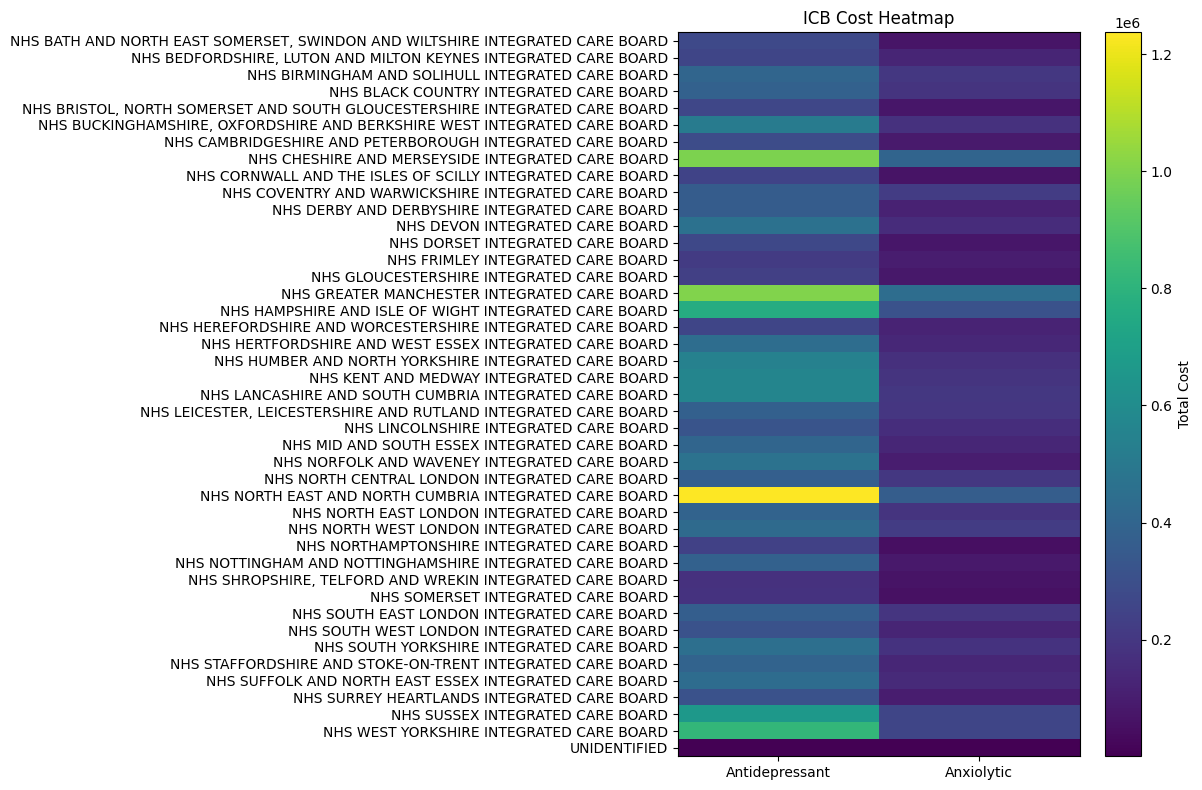

In [81]:
plt.figure(figsize=(12,8))

plt.imshow(
    heatmap_table,
    aspect="auto"
)

plt.colorbar(label="Total Cost")

plt.xticks(
    ticks=np.arange(len(heatmap_table.columns)),
    labels=heatmap_table.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_table.index)),
    labels=heatmap_table.index
)

plt.title(
    "ICB Cost Heatmap"
)

plt.tight_layout()

plt.savefig(
    f"{output_folder}/icb_cost_heatmap.png",
    dpi=300
)

plt.show()

# EXPORT FINAL EXCEL REPORT

In [82]:
excel_path = (
    f"{output_folder}/prescribing_trend_analysis.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    monthly_trend.to_excel(
        writer,
        sheet_name="Monthly Trend",
        index=False
    )

    yearly_trend.to_excel(
        writer,
        sheet_name="Yearly Trend",
        index=False
    )

    icb_summary.to_excel(
        writer,
        sheet_name="ICB Summary",
        index=False
    )

    drug_summary.to_excel(
        writer,
        sheet_name="Drug Summary",
        index=False
    )

    practice_summary.to_excel(
        writer,
        sheet_name="Practice Summary",
        index=False
    )

    comparison_table.to_excel(
        writer,
        sheet_name="Comparison Trend"
    )

print("Excel report saved.")

Excel report saved.


# FINAL SUMMARY

In [83]:
print("="*70)

print("PRESCRIBING TREND ANALYSIS COMPLETED")

print("="*70)

print("Total MH Records:")
print(mh_sample.shape[0])

print("\nDrug Categories:")
print(
    mh_sample["Drug_Category"].value_counts()
)

print("\nTop Medicines:")
print(
    drug_summary.head(10)
)

print("\nTop ICBs:")
print(
    icb_summary.head(10)
)

print("\nTotal Cost:")
print(
    mh_sample[cost_col].sum()
)

print("\nTotal Items:")
print(
    mh_sample[items_col].sum()
)

print("="*70)

PRESCRIBING TREND ANALYSIS COMPLETED
Total MH Records:
1253776

Drug Categories:
Drug_Category
Antidepressant    913404
Anxiolytic        340372
Name: count, dtype: int64

Top Medicines:
         BNF_CHEMICAL_SUBSTANCE   Drug_Category  Total_Items  Total_Quantity  \
38     Sertraline hydrochloride  Antidepressant      2224756      73537384.0   
2   Amitriptyline hydrochloride  Antidepressant      1418271      70658240.0   
29                  Mirtazapine  Antidepressant      1188006      28913204.0   
6       Citalopram hydrobromide  Antidepressant      1072950      35334654.0   
18     Fluoxetine hydrochloride  Antidepressant       645196      29041935.0   
45                  Venlafaxine  Antidepressant       551358      19122999.0   
15     Duloxetine hydrochloride  Antidepressant       459622      15527025.0   
48                    Zopiclone      Anxiolytic       332047       5629620.0   
12                     Diazepam      Anxiolytic       305625       7977282.0   
27           